# Part 1.
Load the 'divorce_margarine' dataset from the 'dslabs' package. Investigate the correlation between margarine consumption and divorce rates in Maine. Would an increase in the preference for margarine lead to skyrocketing divorce rates?

In [1]:
install.packages('dslabs')
install.packages('ggplot2')

Installing package into ‘/usr/local/spark-3.5.2-bin-hadoop3/R/lib’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/spark-3.5.2-bin-hadoop3/R/lib’
(as ‘lib’ is unspecified)



In [2]:
library(dslabs)
library(ggplot2)

In [3]:
str(divorce_margarine)

'data.frame':	10 obs. of  3 variables:
 $ divorce_rate_maine              : num  5 4.7 4.6 4.4 4.3 4.1 4.2 4.2 4.2 4.1
 $ margarine_consumption_per_capita: num  8.2 7 6.5 5.3 5.2 4 4.6 4.5 4.2 3.7
 $ year                            : int  2000 2001 2002 2003 2004 2005 2006 2007 2008 2009


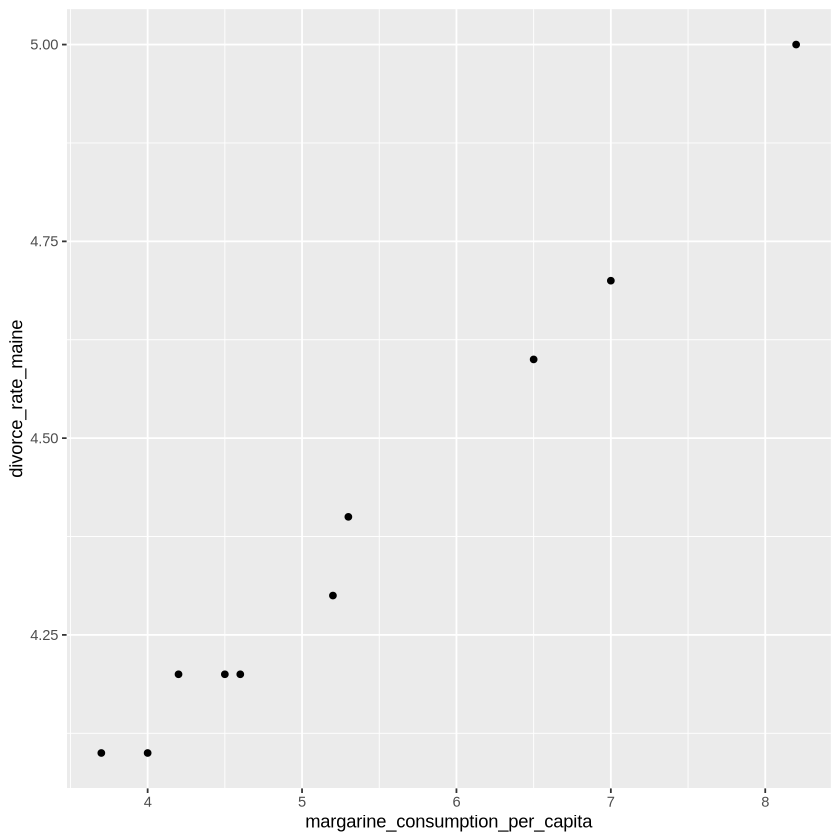

In [4]:
ggplot(divorce_margarine,
       aes(x = margarine_consumption_per_capita,
           y = divorce_rate_maine)) +
    geom_point()

In [5]:
divorce_marg <- lm(divorce_rate_maine ~ margarine_consumption_per_capita, divorce_margarine)
summary(divorce_marg)


Call:
lm(formula = divorce_rate_maine ~ margarine_consumption_per_capita, 
    data = divorce_margarine)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.05583 -0.01816 -0.01452  0.03601  0.04625 

Coefficients:
                                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)                      3.308626   0.048032   68.88 2.20e-12 ***
margarine_consumption_per_capita 0.201386   0.008735   23.05 1.33e-08 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.03841 on 8 degrees of freedom
Multiple R-squared:  0.9852,	Adjusted R-squared:  0.9833 
F-statistic: 531.5 on 1 and 8 DF,  p-value: 1.33e-08


According to the model, it would seem like there is a strong correlation between the two, with a low P-value (P = 1.33e-08), and the model itself fits the data remarkably well, able to explain 98% of the variation. BUT this does not confirm causation, as it might as well be pure coincidence, and logically it would make more sense for it to be so. So, although the data seems to imply the two parametres are interrelated, an increase in margarine consumption is incredibly unlikely to result in a rising divorce rate.

# Part 2.

Load the ‘GSSvocab’ dataset from the ‘car’ package. This dataset contains people’s scores on an English vocabulary test and includes demographic information.
Filter for the year 1978 and remove rows with missing values (the function na.exclude() is one way to do this – check out the documentation!).

When creating plots, try to play around with the options of ggplot2 – add titles and axis labels, and consider using colours.

In [6]:
install.packages('car')

Installing package into ‘/usr/local/spark-3.5.2-bin-hadoop3/R/lib’
(as ‘lib’ is unspecified)

also installing the dependencies ‘backports’, ‘cowplot’, ‘Deriv’, ‘modelr’, ‘microbenchmark’, ‘broom’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘survival’, ‘boot’, ‘minqa’, ‘nloptr’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘nnet’, ‘pbkrtest’, ‘quantreg’, ‘lme4’




In [7]:
install.packages('dplyr')

Installing package into ‘/usr/local/spark-3.5.2-bin-hadoop3/R/lib’
(as ‘lib’ is unspecified)



In [8]:
install.packages('ggplot2')

Installing package into ‘/usr/local/spark-3.5.2-bin-hadoop3/R/lib’
(as ‘lib’ is unspecified)



In [9]:
library(car)
library(dplyr)
library(ggplot2)

Loading required package: carData


Attaching package: ‘dplyr’


The following object is masked from ‘package:car’:

    recode


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [10]:
data(GSSvocab)
str(GSSvocab)

'data.frame':	28867 obs. of  8 variables:
 $ year      : Factor w/ 20 levels "1978","1982",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ gender    : Factor w/ 2 levels "female","male": 1 1 2 1 1 2 2 2 1 2 ...
 $ nativeBorn: Factor w/ 2 levels "no","yes": 2 2 2 2 2 2 2 2 2 2 ...
 $ ageGroup  : Factor w/ 5 levels "18-29","30-39",..: 4 5 2 4 3 1 1 4 3 1 ...
 $ educGroup : Factor w/ 5 levels "<12 yrs","12 yrs",..: 2 1 1 2 2 2 2 2 4 2 ...
 $ vocab     : num  10 6 4 9 6 6 4 7 8 3 ...
 $ age       : num  52 74 35 50 41 19 19 59 49 21 ...
 $ educ      : num  12 9 10 12 12 12 12 12 16 12 ...


In [11]:
dat78 <- GSSvocab %>%
    filter(year == 1978) %>%
    na.exclude()
head(dat78)

,year,gender,nativeBorn,ageGroup,educGroup,vocab,age,educ
,<fct>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>
1978.1,1978,female,yes,50-59,12 yrs,10,52,12
1978.2,1978,female,yes,60+,<12 yrs,6,74,9
1978.3,1978,male,yes,30-39,<12 yrs,4,35,10
1978.4,1978,female,yes,50-59,12 yrs,9,50,12
1978.5,1978,female,yes,40-49,12 yrs,6,41,12
1978.6,1978,male,yes,18-29,12 yrs,6,19,12


**a.**

**Is a person’s score on the vocabulary test (‘vocab’) significantly impacted by their level of education (‘educ’)? Visualize the relationship in a plot and build a model. Briefly explain the results.**

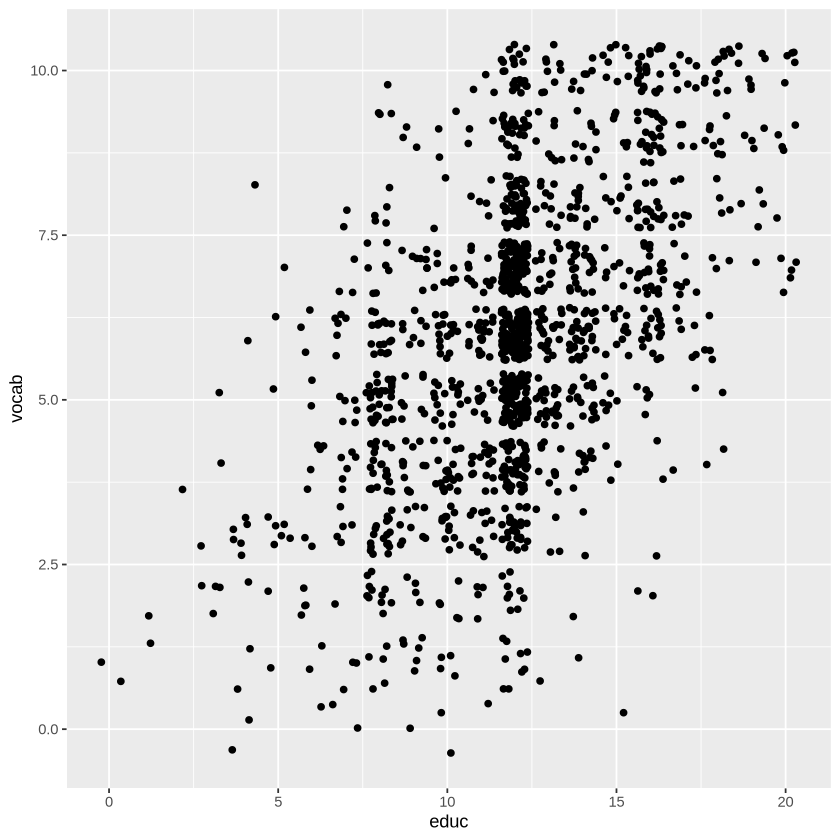

In [12]:
ggplot(dat78,
       aes(x=educ,
           y=vocab)) +
    geom_point(position = 'jitter')

In [13]:
educ_model <- lm(vocab ~ educ, dat78)
summary(educ_model)


Call:
lm(formula = vocab ~ educ, data = dat78)

Residuals:
    Min      1Q  Median      3Q     Max 
-7.1233 -1.1608  0.0542  1.0917  5.6243 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  1.23567    0.19957   6.192  7.7e-10 ***
educ         0.39251    0.01606  24.443  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.885 on 1475 degrees of freedom
Multiple R-squared:  0.2883,	Adjusted R-squared:  0.2878 
F-statistic: 597.5 on 1 and 1475 DF,  p-value: < 2.2e-16


Result: The P-value indicates that it seems to be a significant difference, and there does seem to be a correlation between the vocab level and education. However, the model can only explain/fit around 28% of the variation, which could be improved.

**b.**

Whether a person is the native of an English-speaking country (‘nativeBorn’) could potentially have an impact on the size of their vocabulary. Visualize the relationship and add the predictor to the model. Briefly explain the results.

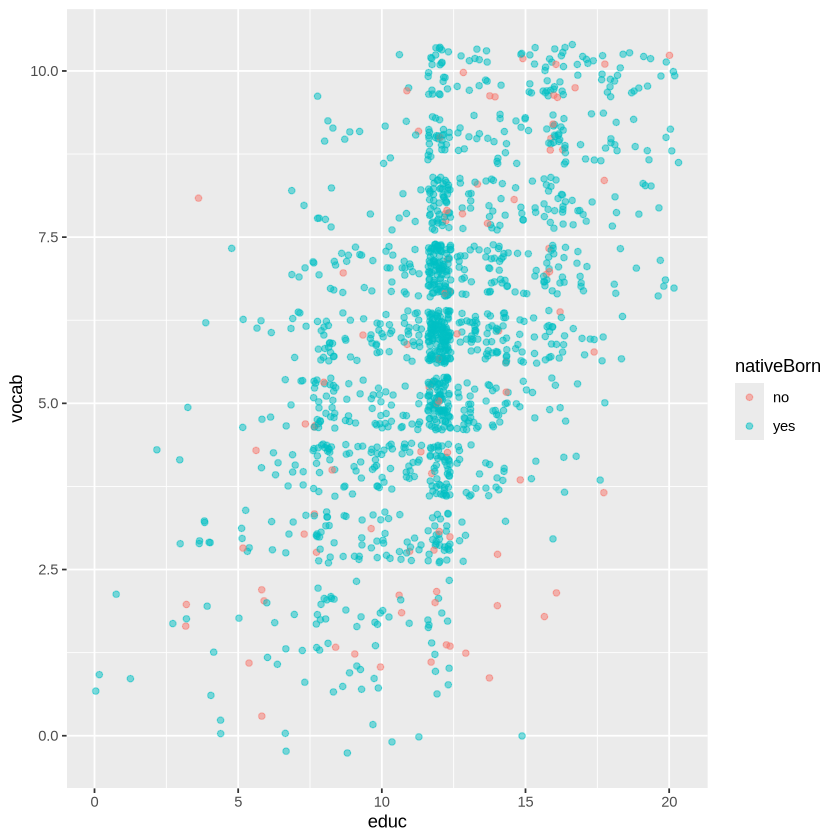

In [14]:
ggplot(dat78,
       aes(x=educ,
           y=vocab,
          color = nativeBorn)) +
    geom_point(position = 'jitter',
              alpha = 0.5)

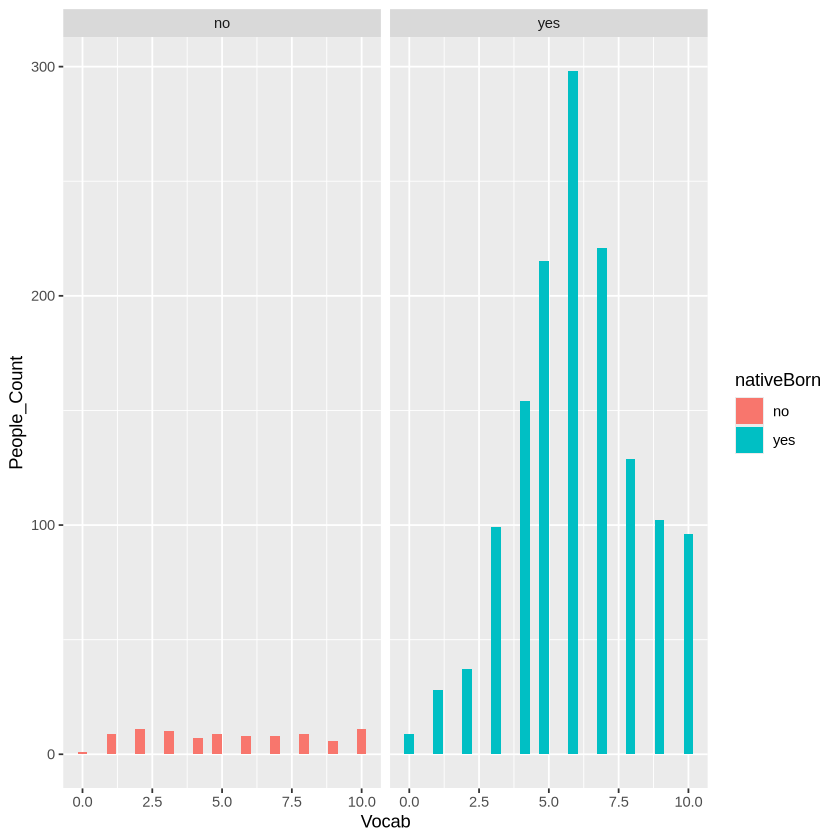

In [15]:
ggplot(dat78,
       aes(x=vocab, fill = nativeBorn)) + 
    geom_histogram(bins =30) +
    facet_wrap(~nativeBorn) +
    labs(x = "Vocab",
         y = "People_Count")

In [16]:
native_model <- lm(vocab ~ educ+nativeBorn, dat78)
summary(native_model)


Call:
lm(formula = vocab ~ educ + nativeBorn, data = dat78)

Residuals:
   Min     1Q Median     3Q    Max 
-7.162 -1.200  0.015  1.231  5.803 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)    0.62803    0.27651   2.271  0.02327 *  
educ           0.39222    0.01601  24.499  < 2e-16 ***
nativeBornyes  0.65032    0.20551   3.164  0.00159 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.879 on 1474 degrees of freedom
Multiple R-squared:  0.2931,	Adjusted R-squared:  0.2921 
F-statistic: 305.6 on 2 and 1474 DF,  p-value: < 2.2e-16


Result: The model has a significant P-value, and is able to explain 29% of the variation. It is however of interest that it seems the model shows more significant deviation from what might be explained by chance for the non-native speakers (P = <2e-16), compared to the native speakers (P = 0.00159). This is likely due to the much lower amount of non-native speakers in the dataset, and should be taken into consideration.

**c.**

**Does a person’s level of education depend on whether they are a native of the country? Visualize the relationship. Do you think it makes sense to add the relationship as an interaction term? Try creating the model and briefly explain the results.**

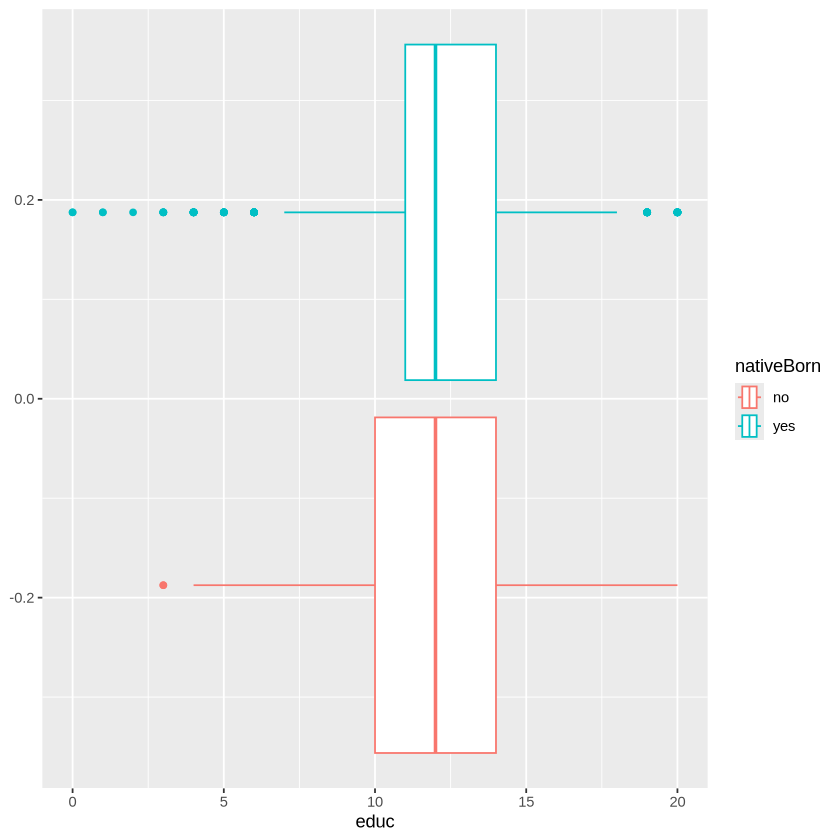

In [17]:
ggplot(dat78,
       aes(x=educ,
           color = nativeBorn)) +
    geom_boxplot()

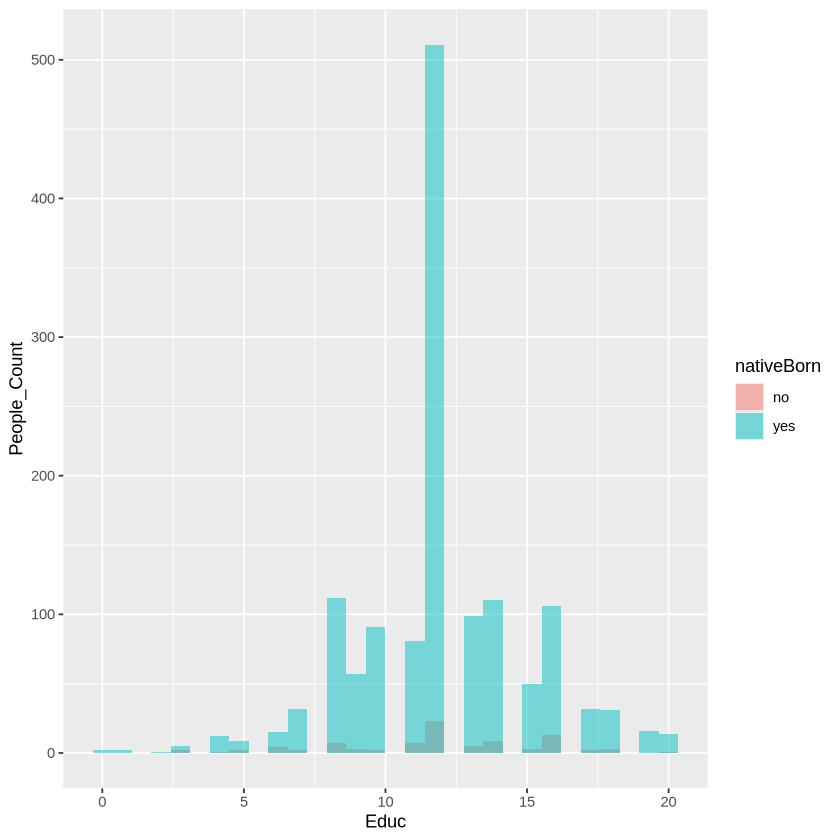

In [18]:
ggplot(dat78,
       aes(x=educ, fill = nativeBorn)) + 
    geom_histogram(bins =30,
                  position = 'identity',
                  alpha = 0.5) +
    labs(x = "Educ",
         y = "People_Count")

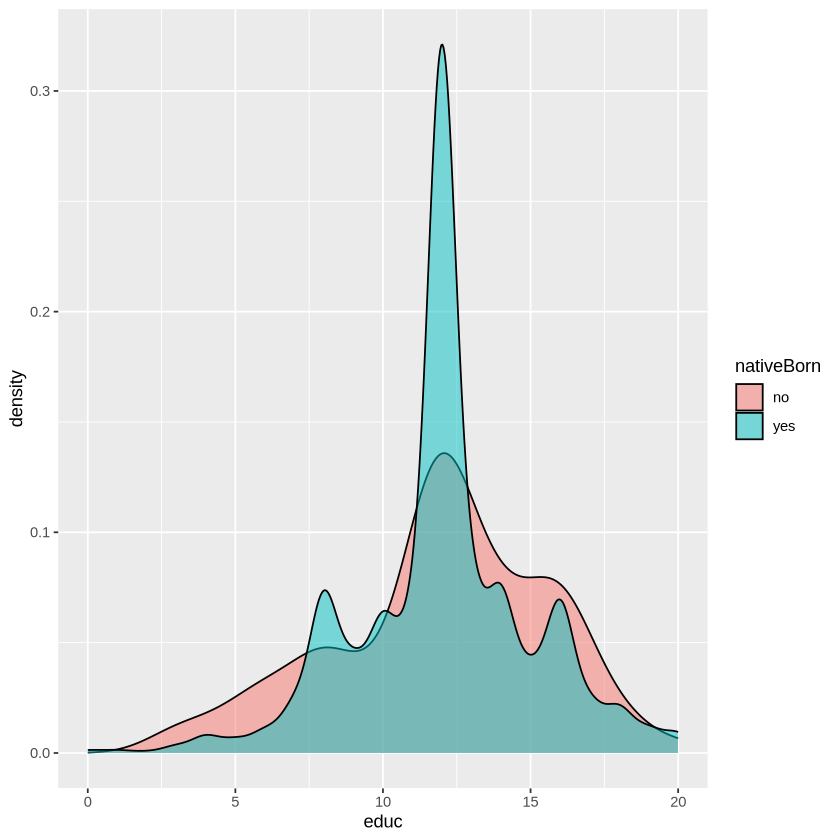

In [19]:
ggplot(dat78,
       aes(x=educ,
           fill = nativeBorn)) +
    geom_density(alpha = 0.5)

There does seem to be a connection between ther native-status and education level, and it would be of interest to try and add it to the model.

In [20]:
native_educ_model <- lm(vocab ~ educ*nativeBorn, dat78)
summary(native_educ_model)


Call:
lm(formula = vocab ~ educ * nativeBorn, data = dat78)

Residuals:
    Min      1Q  Median      3Q     Max 
-7.1554 -1.2049  0.0149  1.2347  5.9857 

Coefficients:
                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)         0.35394    0.68780   0.515    0.607    
educ                0.41510    0.05496   7.553 7.45e-14 ***
nativeBornyes       0.95000    0.71855   1.322    0.186    
educ:nativeBornyes -0.02501    0.05745  -0.435    0.663    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.88 on 1473 degrees of freedom
Multiple R-squared:  0.2932,	Adjusted R-squared:  0.2917 
F-statistic: 203.7 on 3 and 1473 DF,  p-value: < 2.2e-16


Result: The model shows a significant correlation between the predictors and the outcome (P = <2.2e-16), and is able to explain ca. 29% of the variation (Multiple R-squared = 0.2932). But while the model shows a significant change for the non-native participants, the model does not show a significant change for the native participants.

**d.**

**Which model performs best?**

In [21]:
anova(educ_model, native_model, native_educ_model)

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1475,5241.828,NA,NA,NA,NA
2,1474,5206.458,1,35.3707012,10.0082911,0.001590199
3,1473,5205.788,1,0.6695224,0.1894442,0.663443355


Result: The second model performs better than the third model. With a much lower P-value and a higer F-statistic (10 for model 2, 0.6 for model 3), signifying that the differences between the groups is significant, and the larger Sum of Sq-value shows that the model can explain a significant portion of the variability between groups